In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as e:
    PROPHET_AVAILABLE = False
    print("Prophet is not available. SARIMA and Seasonal Naive will still run.")
    print("To enable Prophet, run: !pip install prophet -q")

In [4]:
DRIVE_DIR = Path("/content/drive/MyDrive")

INPUT_FILE = DRIVE_DIR / "model_ready_category_dataset.csv"
SPLIT_SCENARIOS_FILE = DRIVE_DIR / "time_split_scenarios.csv"
EXPERIMENT_CONFIG_FILE = DRIVE_DIR / "experiment_configuration.json"

MODEL_1_OUTPUT_DIR = DRIVE_DIR / "model_1_statistical_baseline_outputs"
MODEL_1_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_OUTPUT_FILE = MODEL_1_OUTPUT_DIR / "model_1_all_forecasts.csv"
VALIDATION_RESULTS_FILE = MODEL_1_OUTPUT_DIR / "model_1_validation_results.csv"
TEST_RESULTS_FILE = MODEL_1_OUTPUT_DIR / "model_1_test_results.csv"
BEST_CONFIG_FILE = MODEL_1_OUTPUT_DIR / "model_1_best_configurations.csv"
EXPERIMENT_LOG_FILE = MODEL_1_OUTPUT_DIR / "model_1_experiment_log.json"

SARIMA_CANDIDATE_CONFIGS = [
    {"order": (0, 1, 1), "seasonal_order": (0, 0, 0, 0), "label": "ARIMA_0_1_1"},
    {"order": (1, 1, 0), "seasonal_order": (0, 0, 0, 0), "label": "ARIMA_1_1_0"},
    {"order": (1, 1, 1), "seasonal_order": (0, 0, 0, 0), "label": "ARIMA_1_1_1"},
    {"order": (0, 1, 1), "seasonal_order": (0, 1, 1, 52), "label": "SARIMA_0_1_1_0_1_1_52"},
    {"order": (1, 1, 0), "seasonal_order": (1, 0, 0, 52), "label": "SARIMA_1_1_0_1_0_0_52"},
]

ETS_CANDIDATE_CONFIGS = [
    {"trend": None, "seasonal": None, "seasonal_periods": None, "label": "SES"},
    {"trend": "add", "seasonal": None, "seasonal_periods": None, "label": "Holt_Additive_Trend"},
    {"trend": None, "seasonal": "add", "seasonal_periods": 52, "label": "ETS_Additive_Seasonal"},
    {"trend": "add", "seasonal": "add", "seasonal_periods": 52, "label": "ETS_Additive_Trend_Seasonal"},
]

MOVING_AVERAGE_WINDOWS = [4, 8, 12, 26]

PROPHET_CANDIDATE_CONFIGS = [
    {
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "daily_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0,
        "label": "Prophet_Additive_Default"
    },
    {
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "daily_seasonality": False,
        "seasonality_mode": "multiplicative",
        "changepoint_prior_scale": 0.05,
        "seasonality_prior_scale": 10.0,
        "label": "Prophet_Multiplicative_Default"
    },
    {
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "daily_seasonality": False,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.1,
        "seasonality_prior_scale": 10.0,
        "label": "Prophet_Additive_FlexibleTrend"
    }
]

SEASONAL_PERIOD = 52

RUN_ALL_CATEGORIES = True
DEBUG_CATEGORY_LIMIT = None

RANDOM_STATE = 42

experiment_log = {
    "run_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "input_file": str(INPUT_FILE),
    "split_scenarios_file": str(SPLIT_SCENARIOS_FILE),
    "sarima_candidate_configs": SARIMA_CANDIDATE_CONFIGS,
    "ets_candidate_configs": ETS_CANDIDATE_CONFIGS,
    "moving_average_windows": MOVING_AVERAGE_WINDOWS,
    "prophet_candidate_configs": PROPHET_CANDIDATE_CONFIGS,
    "seasonal_period": SEASONAL_PERIOD,
    "model_selection_rule": "Select best configuration per category and split scenario using lowest validation MASE, with RMSE as tie-breaker."
}

with open(EXPERIMENT_LOG_FILE, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

In [5]:
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_FILE}")

if not SPLIT_SCENARIOS_FILE.exists():
    raise FileNotFoundError(f"Split scenarios file not found: {SPLIT_SCENARIOS_FILE}")

category_df = pd.read_csv(INPUT_FILE)
split_scenarios = pd.read_csv(SPLIT_SCENARIOS_FILE)

category_df["week_start"] = pd.to_datetime(category_df["week_start"])

required_columns = ["Product Category", "week_start", "weekly_quantity"]
missing_columns = [col for col in required_columns if col not in category_df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

category_df = category_df.sort_values(["Product Category", "week_start"]).reset_index(drop=True)

categories = sorted(category_df["Product Category"].dropna().unique())

if not RUN_ALL_CATEGORIES and DEBUG_CATEGORY_LIMIT is not None:
    categories = categories[:DEBUG_CATEGORY_LIMIT]

print("Category-level dataset loaded successfully.")
print("Shape:", category_df.shape)
print("Number of categories:", len(categories))
print("Date range:", category_df["week_start"].min(), "to", category_df["week_start"].max())
print("Total demand:", category_df["weekly_quantity"].sum())

print("\nSplit scenarios:")
print(split_scenarios)

Category-level dataset loaded successfully.
Shape: (6200, 44)
Number of categories: 40
Date range: 2023-01-09 00:00:00 to 2025-12-22 00:00:00
Total demand: 530935.0

Split scenarios:
      scenario_id  validation_horizon_weeks  test_horizon_weeks          train_start            train_end     validation_start       validation_end           test_start  \
0    val_4_test_4                         4                   4  2023-01-09 00:00:00  2025-10-27 00:00:00  2025-11-03 00:00:00  2025-11-24 00:00:00  2025-12-01 00:00:00   
1    val_4_test_8                         4                   8  2023-01-09 00:00:00  2025-09-29 00:00:00  2025-10-06 00:00:00  2025-10-27 00:00:00  2025-11-03 00:00:00   
2   val_4_test_12                         4                  12  2023-01-09 00:00:00  2025-09-01 00:00:00  2025-09-08 00:00:00  2025-09-29 00:00:00  2025-10-06 00:00:00   
3    val_8_test_4                         8                   4  2023-01-09 00:00:00  2025-09-29 00:00:00  2025-10-06 00:00:00  2

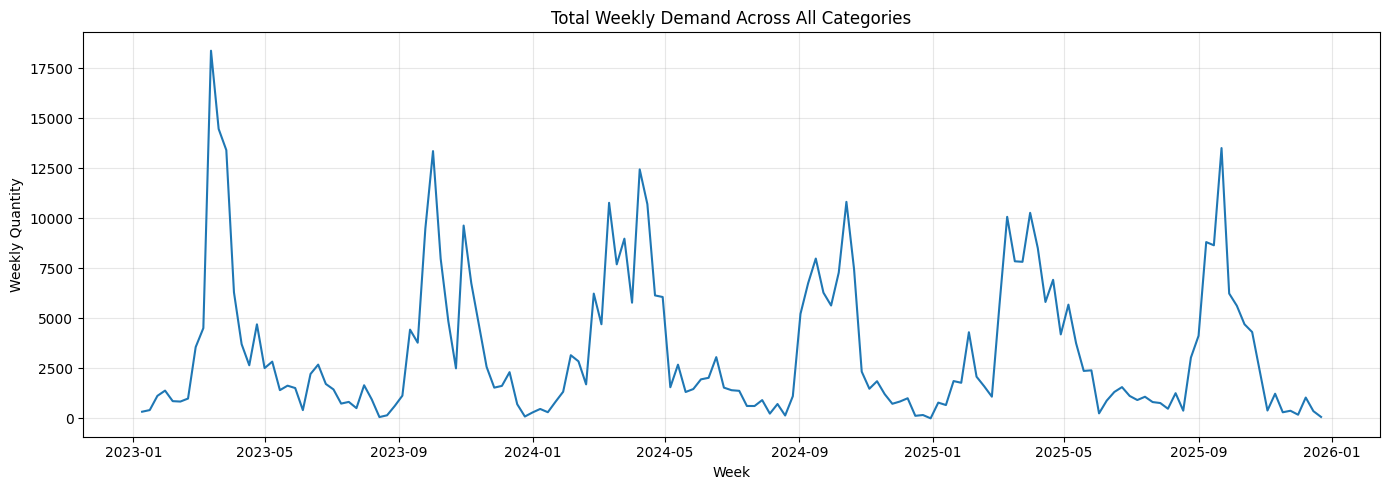

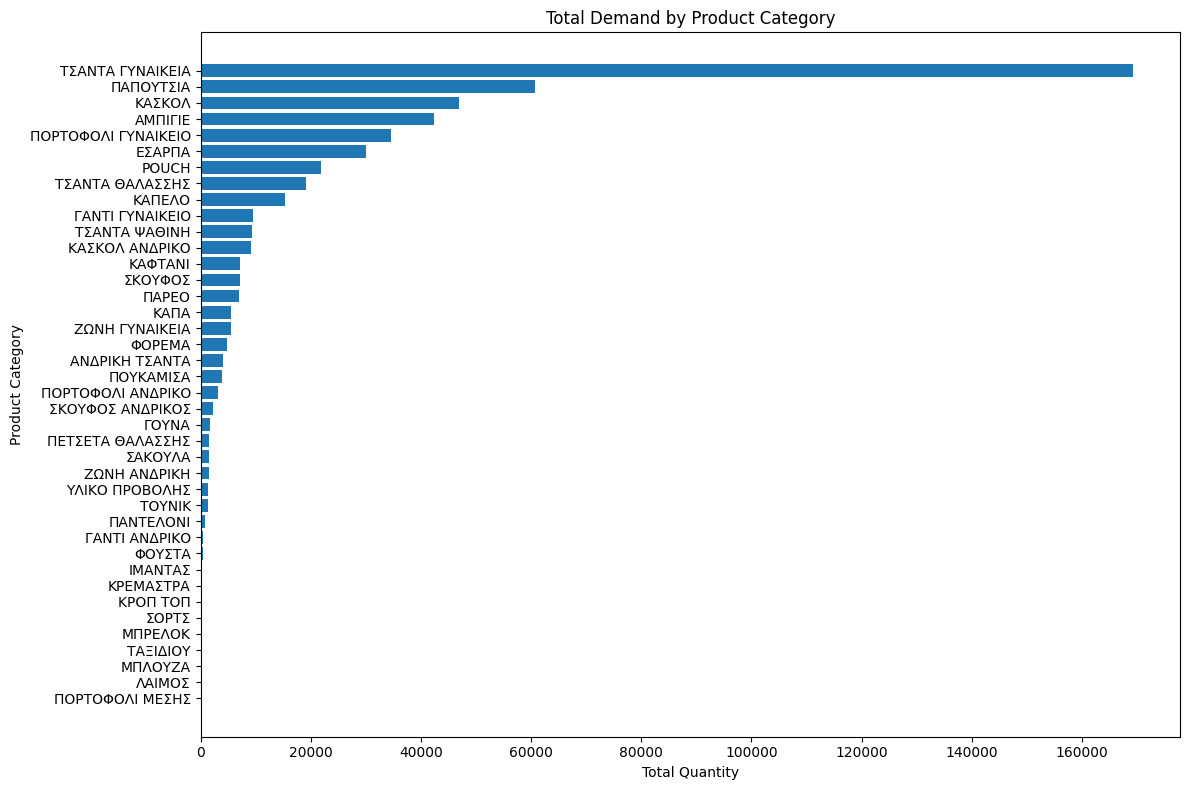

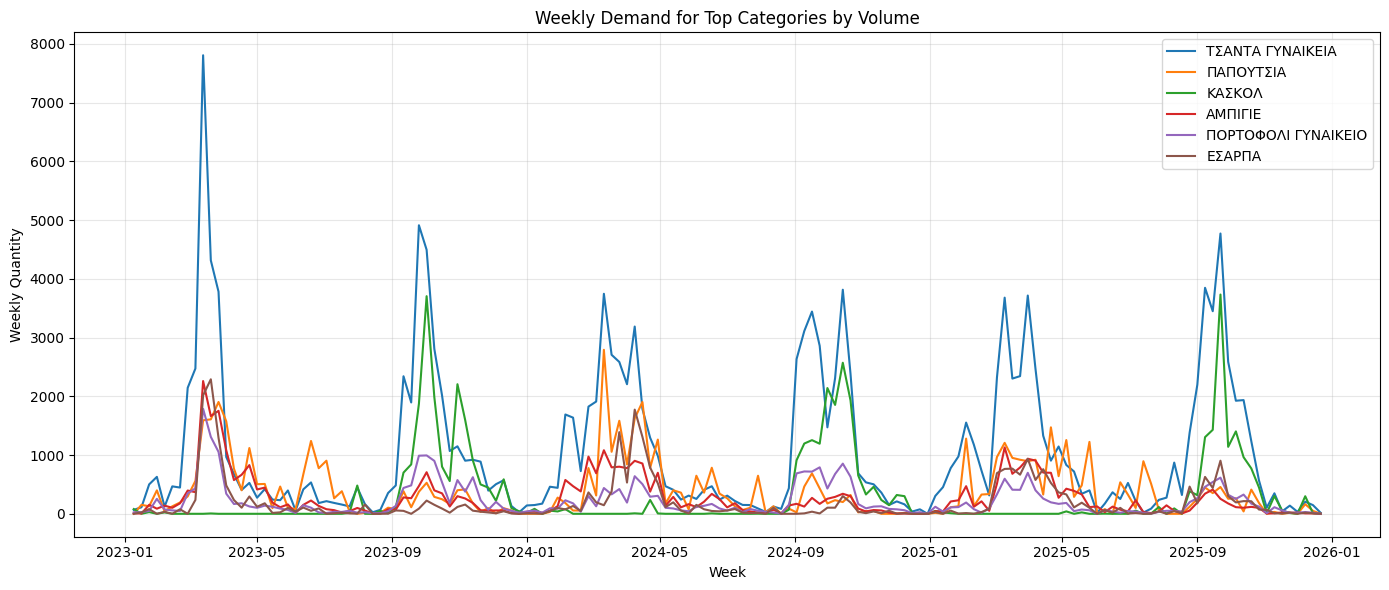

In [6]:
aggregate_weekly = (
    category_df
    .groupby("week_start", as_index=False)
    .agg(total_weekly_quantity=("weekly_quantity", "sum"))
)

plt.figure(figsize=(14, 5))
plt.plot(aggregate_weekly["week_start"], aggregate_weekly["total_weekly_quantity"])
plt.title("Total Weekly Demand Across All Categories")
plt.xlabel("Week")
plt.ylabel("Weekly Quantity")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_1_OUTPUT_DIR / "plot_total_weekly_demand.png", dpi=150)
plt.show()

category_volume = (
    category_df
    .groupby("Product Category", as_index=False)
    .agg(total_quantity=("weekly_quantity", "sum"))
    .sort_values("total_quantity", ascending=False)
)

plt.figure(figsize=(12, 8))
plt.barh(category_volume["Product Category"].astype(str), category_volume["total_quantity"])
plt.title("Total Demand by Product Category")
plt.xlabel("Total Quantity")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(MODEL_1_OUTPUT_DIR / "plot_category_total_demand.png", dpi=150)
plt.show()

top_categories_for_plot = category_volume.head(6)["Product Category"].tolist()

plt.figure(figsize=(14, 6))
for cat in top_categories_for_plot:
    temp = category_df[category_df["Product Category"] == cat]
    plt.plot(temp["week_start"], temp["weekly_quantity"], label=str(cat))
plt.title("Weekly Demand for Top Categories by Volume")
plt.xlabel("Week")
plt.ylabel("Weekly Quantity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_1_OUTPUT_DIR / "plot_top_categories_weekly_demand.png", dpi=150)
plt.show()

In [7]:
def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def root_mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    return np.mean(np.where(denominator == 0, 0, diff / denominator)) * 100


def mase(y_true, y_pred, y_train, seasonality=1):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if len(y_train) <= seasonality:
        return np.nan

    naive_errors = np.abs(y_train[seasonality:] - y_train[:-seasonality])
    scale = np.mean(naive_errors)

    if scale == 0 or np.isnan(scale):
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale


def evaluate_forecast(y_true, y_pred, y_train, seasonality=1):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_train, seasonality=seasonality)
    }

In [8]:
def build_grid(param_grid):
    from itertools import product

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    configs = []
    for combination in product(*values):
        configs.append(dict(zip(keys, combination)))

    return configs

def get_split_data(df, split_column):
    train_df = df[df[split_column] == "train"].copy()
    validation_df = df[df[split_column] == "validation"].copy()
    test_df = df[df[split_column] == "test"].copy()
    return train_df, validation_df, test_df

def make_non_negative_forecast(y_pred):
    return np.maximum(np.asarray(y_pred, dtype=float), 0)

def seasonal_naive_forecast(train_series, horizon, seasonality):
    train_values = np.asarray(train_series, dtype=float)

    if len(train_values) == 0:
        return np.zeros(horizon)

    if len(train_values) < seasonality:
        return np.repeat(train_values[-1], horizon)

    seasonal_values = train_values[-seasonality:]
    repeats = int(np.ceil(horizon / seasonality))
    forecast = np.tile(seasonal_values, repeats)[:horizon]
    return forecast

def moving_average_forecast(train_series, horizon, window):
    train_values = np.asarray(train_series, dtype=float)
    if len(train_values) == 0:
        return np.zeros(horizon)
    effective_window = min(window, len(train_values))
    forecast_value = np.mean(train_values[-effective_window:])
    return np.repeat(forecast_value, horizon)

def fit_ets_and_forecast(train_series, horizon, config):
    train_values = np.asarray(train_series, dtype=float)

    if config["seasonal_periods"] is not None and len(train_values) < 2 * config["seasonal_periods"]:
        return None

    try:
        model = ExponentialSmoothing(
            train_values,
            trend=config["trend"],
            seasonal=config["seasonal"],
            seasonal_periods=config["seasonal_periods"],
            initialization_method="estimated"
        )
        fitted_model = model.fit(optimized=True)
        forecast = fitted_model.forecast(horizon)
        forecast = make_non_negative_forecast(forecast)
        return forecast
    except Exception:
        return None

def fit_sarima_and_forecast(train_series, horizon, config):
    """Fit ARIMA/SARIMA model and return forecast. Returns None if the model fails."""
    try:
        model = SARIMAX(
            train_series,
            order=config["order"],
            seasonal_order=config["seasonal_order"],
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=False
        )
        fitted_model = model.fit(disp=False, maxiter=50)
        forecast = fitted_model.forecast(steps=horizon)
        forecast = make_non_negative_forecast(forecast)
        return forecast
    except Exception:
        return None

def fit_prophet_and_forecast(train_df, horizon_dates, config):
    if not PROPHET_AVAILABLE:
        return None

    prophet_train = train_df[["week_start", "weekly_quantity"]].rename(
        columns={"week_start": "ds", "weekly_quantity": "y"}
    )

    future_df = pd.DataFrame({"ds": horizon_dates})

    try:
        model = Prophet(
            yearly_seasonality=config["yearly_seasonality"],
            weekly_seasonality=config["weekly_seasonality"],
            daily_seasonality=config["daily_seasonality"],
            seasonality_mode=config["seasonality_mode"],
            changepoint_prior_scale=config["changepoint_prior_scale"],
            seasonality_prior_scale=config["seasonality_prior_scale"]
        )
        model.fit(prophet_train)
        forecast_df = model.predict(future_df)
        forecast = forecast_df["yhat"].values
        forecast = make_non_negative_forecast(forecast)
        return forecast
    except Exception:
        return None

def select_best_model(results_df):
    valid_results = results_df.copy()
    valid_results = valid_results.replace([np.inf, -np.inf], np.nan)

    if valid_results["MASE"].notna().any():
        sort_columns = ["MASE", "RMSE", "MAE", "sMAPE"]
    else:
        sort_columns = ["RMSE", "MAE", "sMAPE"]

    return valid_results.sort_values(sort_columns, ascending=True).iloc[0]

In [9]:
sarima_configs = SARIMA_CANDIDATE_CONFIGS
ets_configs = ETS_CANDIDATE_CONFIGS
prophet_configs = PROPHET_CANDIDATE_CONFIGS if PROPHET_AVAILABLE else []

print("Number of Moving Average candidate configurations:", len(MOVING_AVERAGE_WINDOWS))
print("Number of ETS candidate configurations:", len(ets_configs))
print("Number of ARIMA/SARIMA candidate configurations:", len(sarima_configs))
print("Number of Prophet candidate configurations:", len(prophet_configs))

all_validation_results = []
all_test_results = []
all_forecasts = []
best_configurations = []

for _, split_row in split_scenarios.iterrows():
    scenario_id = split_row["scenario_id"]
    split_column = f"split_{scenario_id}"

    if split_column not in category_df.columns:
        raise ValueError(f"Split column not found in model_ready_category_dataset: {split_column}")

    print(f"Running split scenario: {scenario_id}")

    for category in categories:
        category_data = category_df[category_df["Product Category"] == category].copy()
        category_data = category_data.sort_values("week_start")

        train_df, validation_df, test_df = get_split_data(category_data, split_column)

        if train_df.empty or validation_df.empty or test_df.empty:
            print(f"Skipping category {category} in {scenario_id}: empty split.")
            continue

        y_train = train_df["weekly_quantity"].astype(float).values
        y_validation = validation_df["weekly_quantity"].astype(float).values
        y_test = test_df["weekly_quantity"].astype(float).values

        validation_horizon = len(validation_df)
        test_horizon = len(test_df)

        category_validation_results = []

        seasonal_naive_validation_pred = seasonal_naive_forecast(
            train_series=y_train,
            horizon=validation_horizon,
            seasonality=SEASONAL_PERIOD
        )

        metrics = evaluate_forecast(
            y_true=y_validation,
            y_pred=seasonal_naive_validation_pred,
            y_train=y_train,
            seasonality=1
        )

        result = {
            "scenario_id": scenario_id,
            "Product Category": category,
            "model_family": "SeasonalNaive",
            "config_id": "seasonal_naive_52",
            "config": json.dumps({"seasonality": SEASONAL_PERIOD}),
            **metrics
        }
        category_validation_results.append(result)
        all_validation_results.append(result)

        for window in MOVING_AVERAGE_WINDOWS:
            validation_pred = moving_average_forecast(
                train_series=y_train,
                horizon=validation_horizon,
                window=window
            )

            metrics = evaluate_forecast(
                y_true=y_validation,
                y_pred=validation_pred,
                y_train=y_train,
                seasonality=1
            )

            result = {
                "scenario_id": scenario_id,
                "Product Category": category,
                "model_family": "MovingAverage",
                "config_id": f"moving_average_{window}",
                "config": json.dumps({"window": window}),
                **metrics
            }
            category_validation_results.append(result)
            all_validation_results.append(result)

        for config in ets_configs:
            validation_pred = fit_ets_and_forecast(
                train_series=y_train,
                horizon=validation_horizon,
                config=config
            )

            if validation_pred is None:
                continue

            metrics = evaluate_forecast(
                y_true=y_validation,
                y_pred=validation_pred,
                y_train=y_train,
                seasonality=1
            )

            result = {
                "scenario_id": scenario_id,
                "Product Category": category,
                "model_family": "ETS",
                "config_id": config["label"],
                "config": json.dumps(config),
                **metrics
            }
            category_validation_results.append(result)
            all_validation_results.append(result)

        for config in sarima_configs:
            validation_pred = fit_sarima_and_forecast(
                train_series=y_train,
                horizon=validation_horizon,
                config=config
            )

            if validation_pred is None:
                continue

            metrics = evaluate_forecast(
                y_true=y_validation,
                y_pred=validation_pred,
                y_train=y_train,
                seasonality=1
            )

            serializable_config = {
                "order": config["order"],
                "seasonal_order": config["seasonal_order"],
                "label": config["label"]
            }

            result = {
                "scenario_id": scenario_id,
                "Product Category": category,
                "model_family": "ARIMA_SARIMA",
                "config_id": config["label"],
                "config": json.dumps(serializable_config),
                **metrics
            }
            category_validation_results.append(result)
            all_validation_results.append(result)

        if PROPHET_AVAILABLE:
            for i, config in enumerate(prophet_configs):
                config_id = config["label"]

                validation_pred = fit_prophet_and_forecast(
                    train_df=train_df,
                    horizon_dates=validation_df["week_start"].values,
                    config=config
                )

                if validation_pred is None:
                    continue

                metrics = evaluate_forecast(
                    y_true=y_validation,
                    y_pred=validation_pred,
                    y_train=y_train,
                    seasonality=1
                )

                result = {
                    "scenario_id": scenario_id,
                    "Product Category": category,
                    "model_family": "Prophet",
                    "config_id": config_id,
                    "config": json.dumps(config),
                    **metrics
                }
                category_validation_results.append(result)
                all_validation_results.append(result)

        category_validation_df = pd.DataFrame(category_validation_results)

        if category_validation_df.empty:
            print(f"No successful model for category {category} in {scenario_id}.")
            continue

        best_row = select_best_model(category_validation_df)
        best_configurations.append(best_row.to_dict())

        best_model_family = best_row["model_family"]
        best_config = json.loads(best_row["config"])

        train_validation_df = pd.concat([train_df, validation_df], axis=0).sort_values("week_start")
        y_train_validation = train_validation_df["weekly_quantity"].astype(float).values

        if best_model_family == "SeasonalNaive":
            test_pred = seasonal_naive_forecast(
                train_series=y_train_validation,
                horizon=test_horizon,
                seasonality=best_config["seasonality"]
            )

        elif best_model_family == "MovingAverage":
            test_pred = moving_average_forecast(
                train_series=y_train_validation,
                horizon=test_horizon,
                window=best_config["window"]
            )

        elif best_model_family == "ETS":
            test_pred = fit_ets_and_forecast(
                train_series=y_train_validation,
                horizon=test_horizon,
                config=best_config
            )

        elif best_model_family == "ARIMA_SARIMA":
            best_config["order"] = tuple(best_config["order"])
            best_config["seasonal_order"] = tuple(best_config["seasonal_order"])
            test_pred = fit_sarima_and_forecast(
                train_series=y_train_validation,
                horizon=test_horizon,
                config=best_config
            )

        elif best_model_family == "Prophet":
            test_pred = fit_prophet_and_forecast(
                train_df=train_validation_df,
                horizon_dates=test_df["week_start"].values,
                config=best_config
            )

        else:
            raise ValueError(f"Unknown model family: {best_model_family}")

        if test_pred is None:
            print(f"Best model failed on test refit for category {category} in {scenario_id}.")
            continue

        test_metrics = evaluate_forecast(
            y_true=y_test,
            y_pred=test_pred,
            y_train=y_train_validation,
            seasonality=1
        )

        test_result = {
            "scenario_id": scenario_id,
            "Product Category": category,
            "selected_model_family": best_model_family,
            "selected_config_id": best_row["config_id"],
            "selected_config": json.dumps(best_config),
            **test_metrics
        }
        all_test_results.append(test_result)

        forecast_temp = test_df[["Product Category", "week_start", "weekly_quantity"]].copy()
        forecast_temp["scenario_id"] = scenario_id
        forecast_temp["model_family"] = best_model_family
        forecast_temp["config_id"] = best_row["config_id"]
        forecast_temp["y_true"] = y_test
        forecast_temp["y_pred"] = test_pred
        forecast_temp["absolute_error"] = np.abs(forecast_temp["y_true"] - forecast_temp["y_pred"])
        all_forecasts.append(forecast_temp)

        print(
            f"Category: {category} | Split: {scenario_id} | "
            f"Best: {best_model_family} | Test MAE: {test_metrics['MAE']:.3f} | "
            f"RMSE: {test_metrics['RMSE']:.3f} | MASE: {test_metrics['MASE']:.3f}"
        )

        pd.DataFrame(all_validation_results).to_csv(VALIDATION_RESULTS_FILE, index=False, encoding="utf-8-sig")
        pd.DataFrame(all_test_results).to_csv(TEST_RESULTS_FILE, index=False, encoding="utf-8-sig")
        pd.DataFrame(best_configurations).to_csv(BEST_CONFIG_FILE, index=False, encoding="utf-8-sig")
        if all_forecasts:
            pd.concat(all_forecasts, ignore_index=True).to_csv(FORECAST_OUTPUT_FILE, index=False, encoding="utf-8-sig")

Number of Moving Average candidate configurations: 4
Number of ETS candidate configurations: 4
Number of ARIMA/SARIMA candidate configurations: 5
Number of Prophet candidate configurations: 3
Running split scenario: val_4_test_4
Category: AΜΠΙΓΙΕ | Split: val_4_test_4 | Best: ETS | Test MAE: 9.000 | RMSE: 11.619 | MASE: 0.067
Category: POUCH | Split: val_4_test_4 | Best: ARIMA_SARIMA | Test MAE: 44.260 | RMSE: 50.344 | MASE: 0.485
Category: ΑΝΔΡΙΚΗ ΤΣΑΝΤΑ | Split: val_4_test_4 | Best: ARIMA_SARIMA | Test MAE: 6.233 | RMSE: 7.839 | MASE: 0.309
Category: ΓΑΝΤΙ ΑΝΔΡΙΚΟ | Split: val_4_test_4 | Best: ARIMA_SARIMA | Test MAE: 0.518 | RMSE: 0.806 | MASE: 0.206
Category: ΓΑΝΤΙ ΓΥΝΑΙΚΕΙΟ | Split: val_4_test_4 | Best: MovingAverage | Test MAE: 89.846 | RMSE: 91.814 | MASE: 1.538
Category: ΓΟΥΝΑ | Split: val_4_test_4 | Best: SeasonalNaive | Test MAE: 11.500 | RMSE: 15.313 | MASE: 1.120
Category: ΕΣΑΡΠΑ | Split: val_4_test_4 | Best: SeasonalNaive | Test MAE: 5.500 | RMSE: 7.141 | MASE: 0.040
Categ

In [10]:
validation_results_df = pd.DataFrame(all_validation_results)
test_results_df = pd.DataFrame(all_test_results)
best_configurations_df = pd.DataFrame(best_configurations)
forecasts_df = pd.concat(all_forecasts, ignore_index=True) if all_forecasts else pd.DataFrame()

validation_results_df.to_csv(VALIDATION_RESULTS_FILE, index=False, encoding="utf-8-sig")
test_results_df.to_csv(TEST_RESULTS_FILE, index=False, encoding="utf-8-sig")
best_configurations_df.to_csv(BEST_CONFIG_FILE, index=False, encoding="utf-8-sig")
forecasts_df.to_csv(FORECAST_OUTPUT_FILE, index=False, encoding="utf-8-sig")

print("\nModel 1 experiment completed.")
print(f"Validation results saved to: {VALIDATION_RESULTS_FILE}")
print(f"Test results saved to: {TEST_RESULTS_FILE}")
print(f"Best configurations saved to: {BEST_CONFIG_FILE}")
print(f"Forecasts saved to: {FORECAST_OUTPUT_FILE}")


Model 1 experiment completed.
Validation results saved to: /content/drive/MyDrive/model_1_statistical_baseline_outputs/model_1_validation_results.csv
Test results saved to: /content/drive/MyDrive/model_1_statistical_baseline_outputs/model_1_test_results.csv
Best configurations saved to: /content/drive/MyDrive/model_1_statistical_baseline_outputs/model_1_best_configurations.csv
Forecasts saved to: /content/drive/MyDrive/model_1_statistical_baseline_outputs/model_1_all_forecasts.csv


In [11]:
print("\nValidation results shape:", validation_results_df.shape)
print("Test results shape:", test_results_df.shape)
print("Forecasts shape:", forecasts_df.shape)

validation_summary = (
    validation_results_df
    .groupby(["scenario_id", "model_family"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        mean_MASE=("MASE", "mean"),
        successful_runs=("Product Category", "count")
    )
    .sort_values(["scenario_id", "mean_MASE", "mean_RMSE"])
)

validation_summary_file = MODEL_1_OUTPUT_DIR / "model_1_validation_summary_by_family.csv"
validation_summary.to_csv(validation_summary_file, index=False, encoding="utf-8-sig")

print("\nValidation summary by model family:")
print(validation_summary)

test_summary = (
    test_results_df
    .groupby(["scenario_id", "selected_model_family"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        mean_MASE=("MASE", "mean"),
        categories=("Product Category", "count")
    )
    .sort_values(["scenario_id", "mean_MASE", "mean_RMSE"])
)

test_summary_file = MODEL_1_OUTPUT_DIR / "model_1_test_summary_selected_models.csv"
test_summary.to_csv(test_summary_file, index=False, encoding="utf-8-sig")

print("\nTest summary of selected models:")
print(test_summary)

selected_model_counts = (
    test_results_df
    .groupby(["scenario_id", "selected_model_family"], as_index=False)
    .agg(selected_count=("Product Category", "count"))
    .sort_values(["scenario_id", "selected_count"], ascending=[True, False])
)

selected_model_counts_file = MODEL_1_OUTPUT_DIR / "model_1_selected_model_counts.csv"
selected_model_counts.to_csv(selected_model_counts_file, index=False, encoding="utf-8-sig")

print("\nSelected model counts:")
print(selected_model_counts)


Validation results shape: (6120, 9)
Test results shape: (360, 9)
Forecasts shape: (2880, 9)

Validation summary by model family:
       scenario_id   model_family    mean_MAE   mean_RMSE  mean_sMAPE  mean_MASE  successful_runs
4   val_12_test_12  SeasonalNaive   59.868750   96.396211   79.333088   1.270668               40
3   val_12_test_12        Prophet   63.868204   95.900675  118.083318   1.462407              120
1   val_12_test_12            ETS   77.561771  118.647208  124.866363   1.544708              160
0   val_12_test_12   ARIMA_SARIMA   87.955813  132.485808  131.438332   1.545990              200
2   val_12_test_12  MovingAverage  109.990024  153.953816  135.143374   1.914488              160
9    val_12_test_4  SeasonalNaive   73.539583  107.025543   64.481761   1.530895               40
5    val_12_test_4   ARIMA_SARIMA   92.030084  117.488296  110.127366   1.673381              200
6    val_12_test_4            ETS   89.247394  113.445471  108.968022   1.781186      

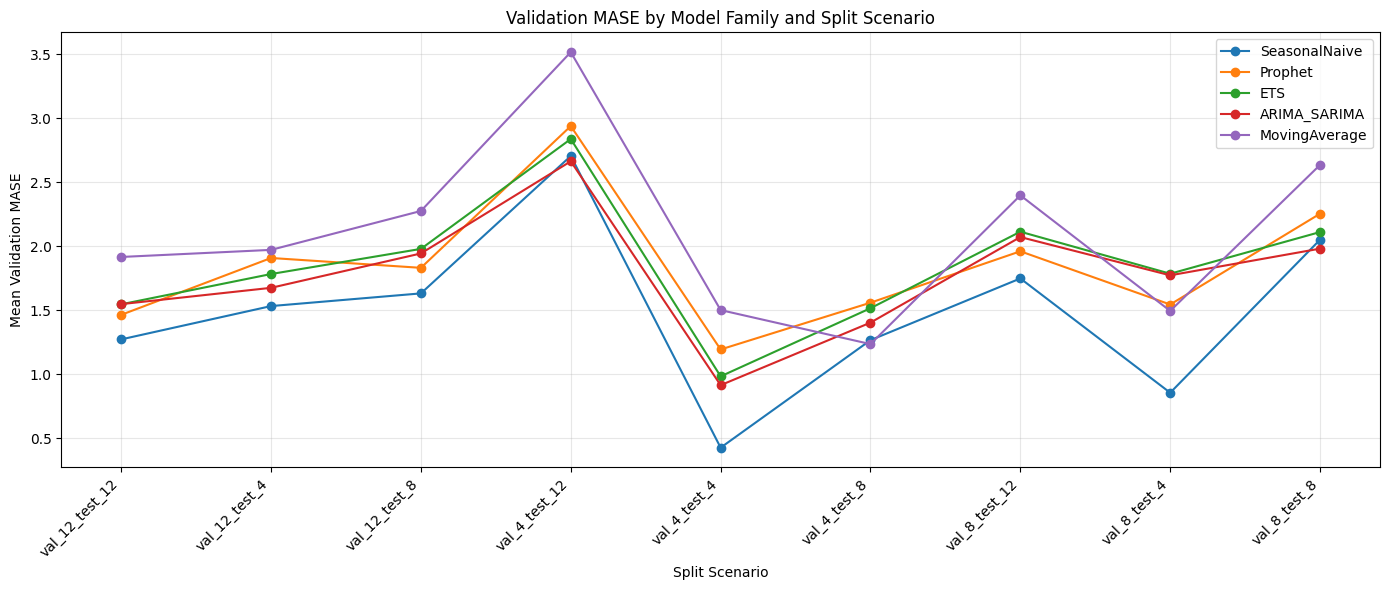

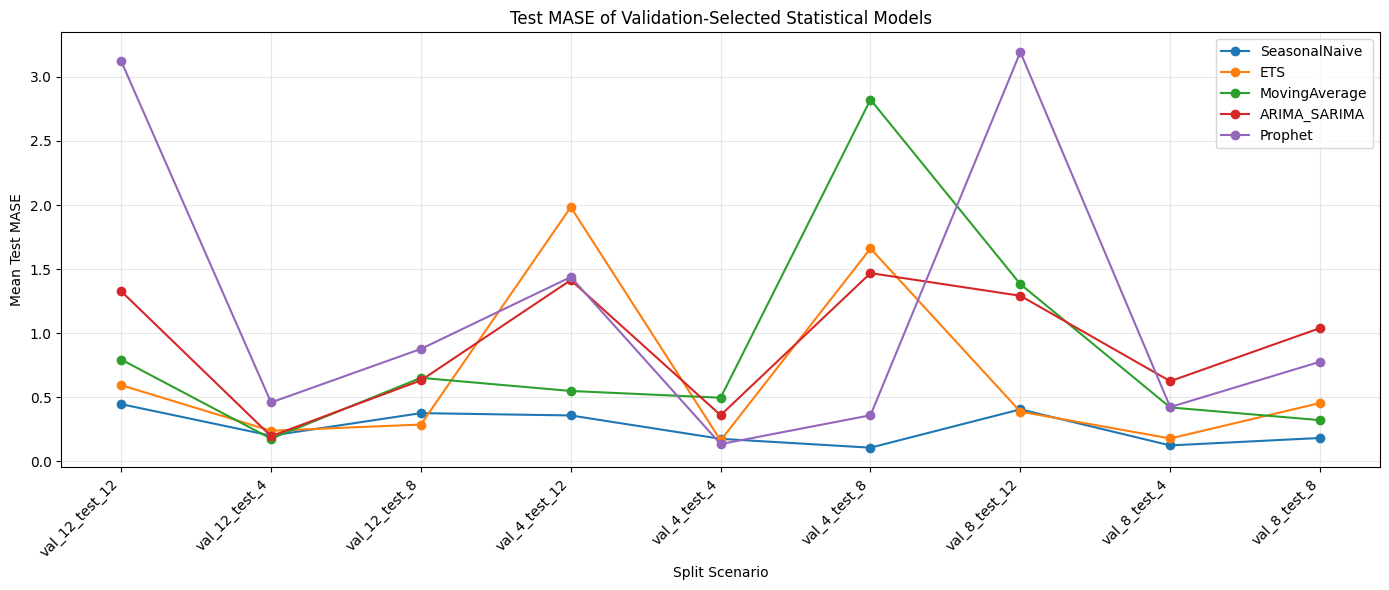

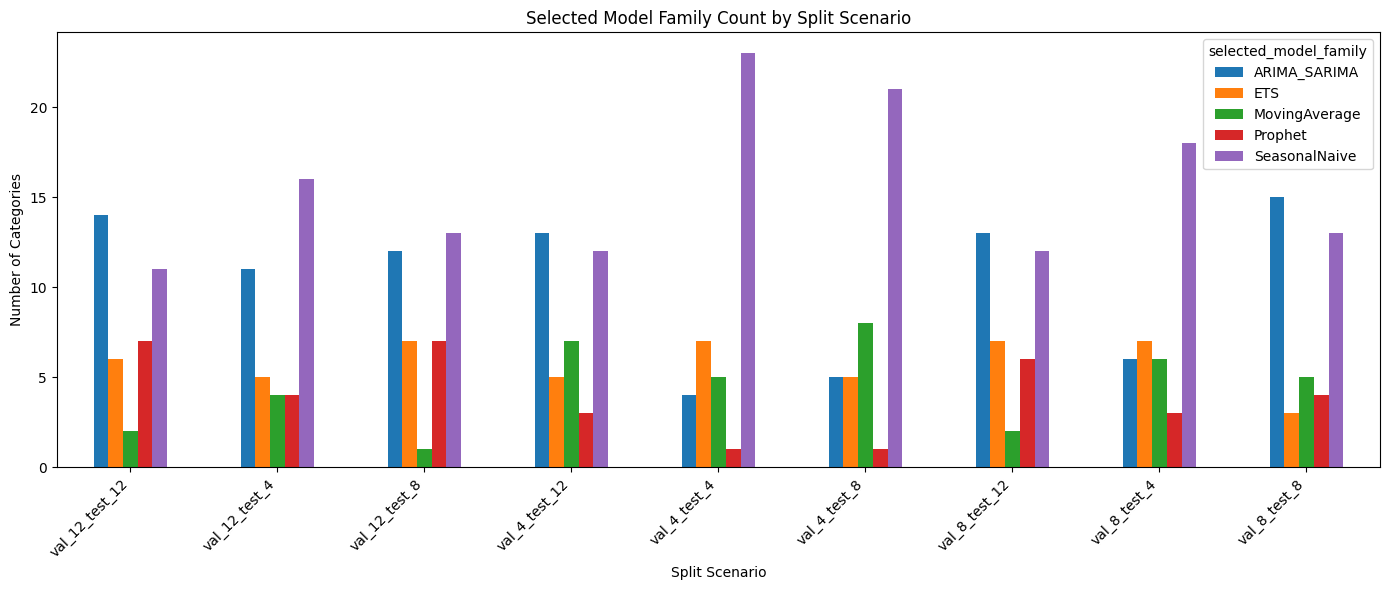

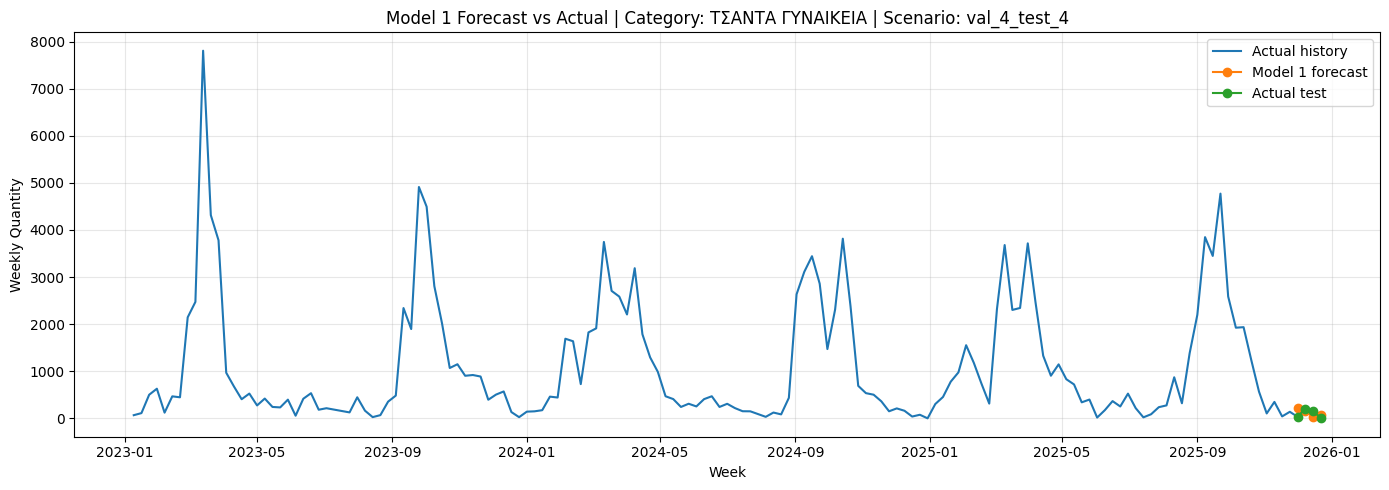

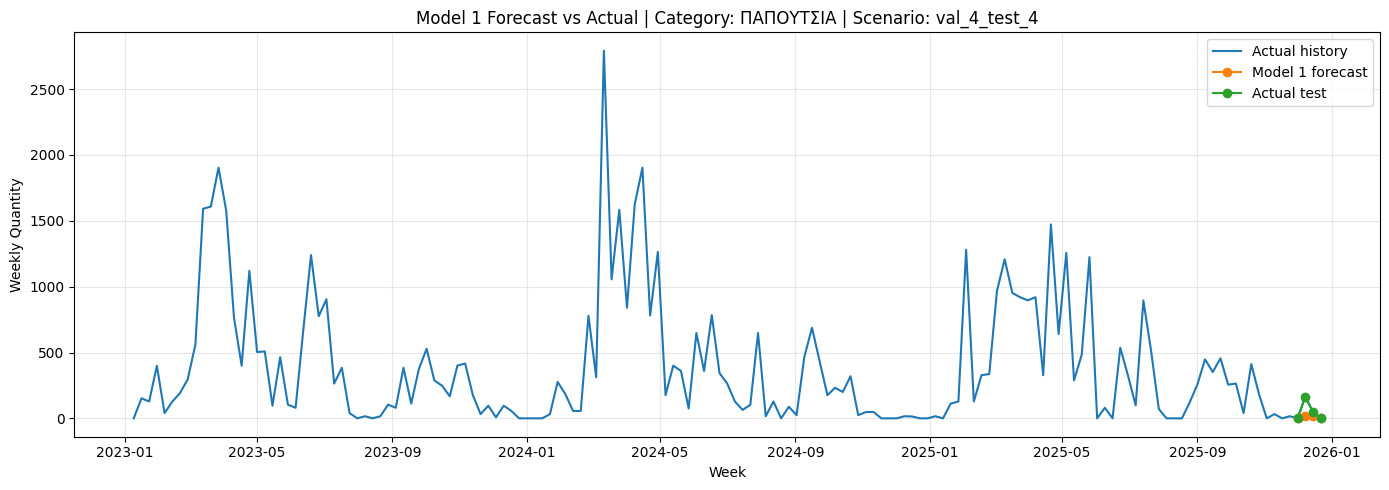

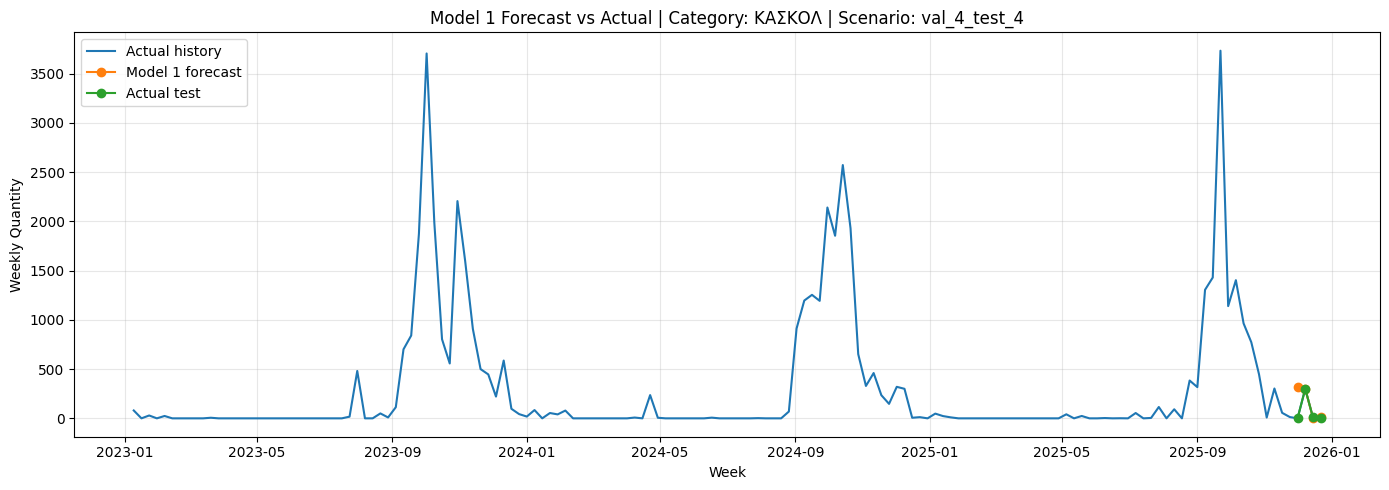

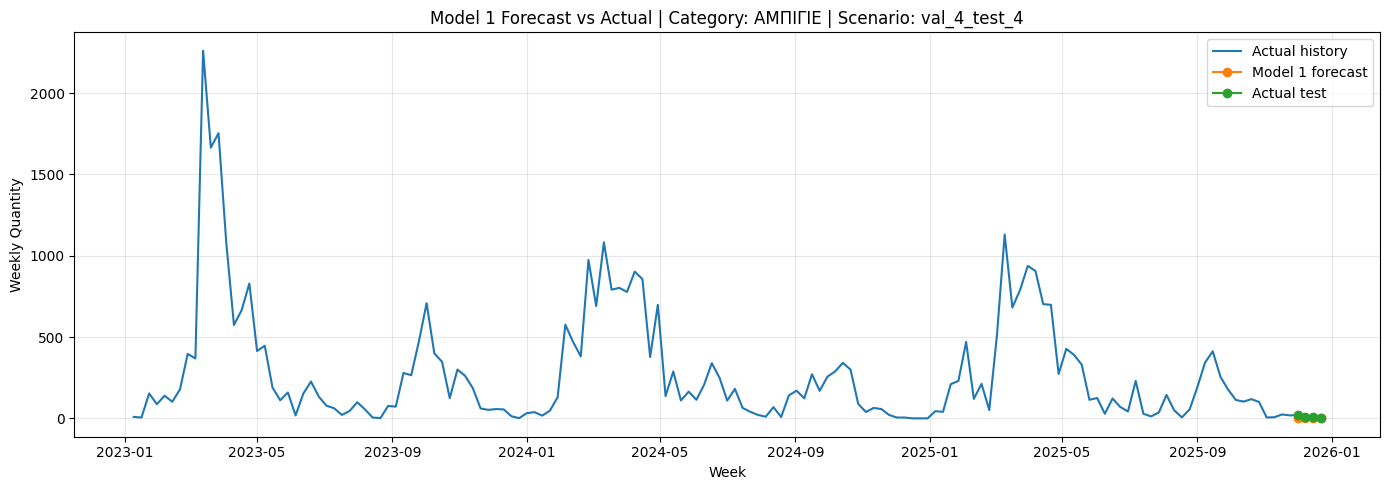

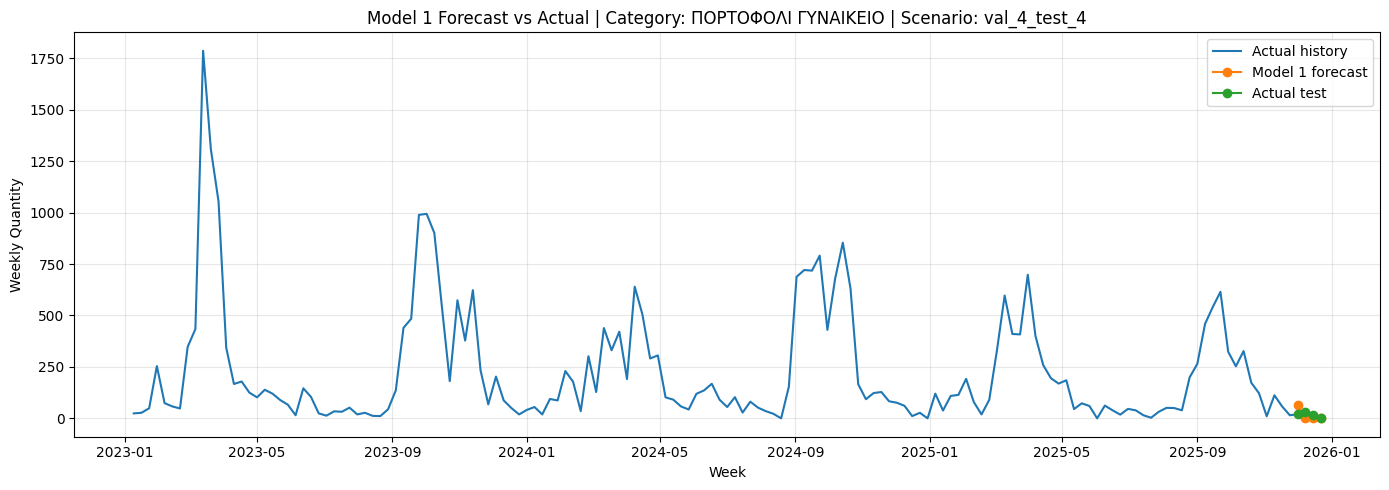

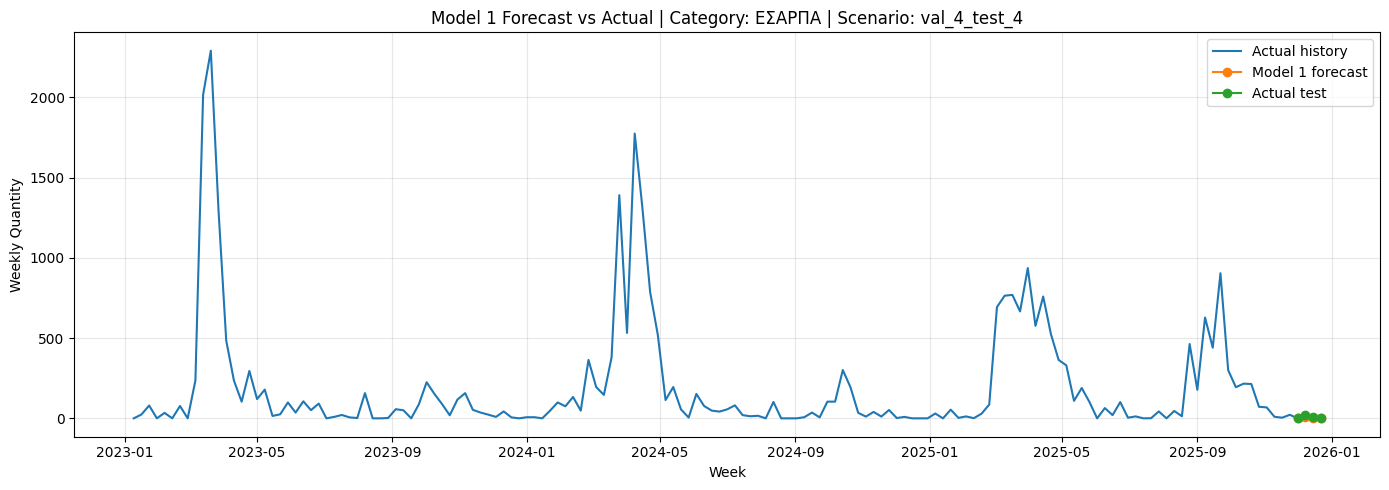

In [12]:
if not validation_summary.empty:
    plt.figure(figsize=(14, 6))
    for model_family in validation_summary["model_family"].unique():
        temp = validation_summary[validation_summary["model_family"] == model_family]
        plt.plot(temp["scenario_id"], temp["mean_MASE"], marker="o", label=model_family)
    plt.title("Validation MASE by Model Family and Split Scenario")
    plt.xlabel("Split Scenario")
    plt.ylabel("Mean Validation MASE")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_1_OUTPUT_DIR / "plot_validation_mase_by_model_family.png", dpi=150)
    plt.show()

if not test_summary.empty:
    plt.figure(figsize=(14, 6))
    for model_family in test_summary["selected_model_family"].unique():
        temp = test_summary[test_summary["selected_model_family"] == model_family]
        plt.plot(temp["scenario_id"], temp["mean_MASE"], marker="o", label=model_family)
    plt.title("Test MASE of Validation-Selected Statistical Models")
    plt.xlabel("Split Scenario")
    plt.ylabel("Mean Test MASE")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(MODEL_1_OUTPUT_DIR / "plot_test_mase_selected_models.png", dpi=150)
    plt.show()

if not selected_model_counts.empty:
    pivot_counts = selected_model_counts.pivot_table(
        index="scenario_id",
        columns="selected_model_family",
        values="selected_count",
        fill_value=0
    )

    pivot_counts.plot(kind="bar", figsize=(14, 6))
    plt.title("Selected Model Family Count by Split Scenario")
    plt.xlabel("Split Scenario")
    plt.ylabel("Number of Categories")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(MODEL_1_OUTPUT_DIR / "plot_selected_model_counts.png", dpi=150)
    plt.show()

if not forecasts_df.empty:
    plot_scenario = forecasts_df["scenario_id"].iloc[0]
    plot_categories = top_categories_for_plot

    for category in plot_categories:
        actual_history = category_df[category_df["Product Category"] == category].copy()
        forecast_plot = forecasts_df[
            (forecasts_df["Product Category"] == category) &
            (forecasts_df["scenario_id"] == plot_scenario)
        ].copy()

        if forecast_plot.empty:
            continue

        plt.figure(figsize=(14, 5))
        plt.plot(actual_history["week_start"], actual_history["weekly_quantity"], label="Actual history")
        plt.plot(forecast_plot["week_start"], forecast_plot["y_pred"], marker="o", label="Model 1 forecast")
        plt.plot(forecast_plot["week_start"], forecast_plot["y_true"], marker="o", label="Actual test")
        plt.title(f"Model 1 Forecast vs Actual | Category: {category} | Scenario: {plot_scenario}")
        plt.xlabel("Week")
        plt.ylabel("Weekly Quantity")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        safe_category_name = str(category).replace("/", "_").replace(" ", "_")
        plt.savefig(MODEL_1_OUTPUT_DIR / f"plot_forecast_vs_actual_{safe_category_name}_{plot_scenario}.png", dpi=150)
        plt.show()

In [13]:
files_to_check = [
    FORECAST_OUTPUT_FILE,
    VALIDATION_RESULTS_FILE,
    TEST_RESULTS_FILE,
    BEST_CONFIG_FILE,
    validation_summary_file,
    test_summary_file,
    selected_model_counts_file,
    EXPERIMENT_LOG_FILE
]

print("\nOutput file verification:")
for file_path in files_to_check:
    if not file_path.exists():
        raise FileNotFoundError(f"Expected file not created: {file_path}")

    file_size_mb = file_path.stat().st_size / (1024 ** 2)
    modified_time = datetime.fromtimestamp(file_path.stat().st_mtime)

    print(f"{file_path.name} | size: {file_size_mb:.3f} MB | modified: {modified_time}")

print("\nModel 1 Statistical Baseline notebook completed successfully.")


Output file verification:
model_1_all_forecasts.csv | size: 0.288 MB | modified: 2026-06-07 18:40:20
model_1_validation_results.csv | size: 1.325 MB | modified: 2026-06-07 18:40:20
model_1_test_results.csv | size: 0.066 MB | modified: 2026-06-07 18:40:20
model_1_best_configurations.csv | size: 0.067 MB | modified: 2026-06-07 18:40:20
model_1_validation_summary_by_family.csv | size: 0.004 MB | modified: 2026-06-07 18:40:21
model_1_test_summary_selected_models.csv | size: 0.004 MB | modified: 2026-06-07 18:40:21
model_1_selected_model_counts.csv | size: 0.001 MB | modified: 2026-06-07 18:40:21
model_1_experiment_log.json | size: 0.003 MB | modified: 2026-06-07 17:50:00

Model 1 Statistical Baseline notebook completed successfully.



Category-level error summary:
     Product Category    mean_MAE   mean_RMSE  mean_sMAPE  mean_MASE  scenarios
5               ΓΟΥΝΑ   32.535547   35.750904  127.381323   3.450946          9
3       ΓΑΝΤΙ ΑΝΔΡΙΚΟ    6.909920    8.795211  105.912244   3.251009          9
30   ΣΚΟΥΦΟΣ ΑΝΔΡΙΚΟΣ   32.834684   38.209053  156.164329   2.698185          9
4     ΓΑΝΤΙ ΓΥΝΑΙΚΕΙΟ  134.132555  149.046945  135.123625   2.383886          9
12               ΚΑΠΑ   40.811500   48.270338  138.025384   1.788920          9
11             ΚAΣΚΟΛ  295.988604  374.790400  131.779826   1.532959          9
2      ΑΝΔΡΙΚΗ ΤΣΑΝΤΑ   23.542373   27.960232  114.160173   1.165233          9
24  ΠΟΡΤΟΦΟΛΙ ΑΝΔΡΙΚΟ   19.347213   21.926419  121.977034   1.077189          9
29            ΣΚΟΥΦΟΣ   36.734283   45.945415  125.524914   0.951212          9
7        ΖΩΝΗ ΑΝΔΡΙΚΗ    9.684558   11.418811  110.072814   0.948807          9


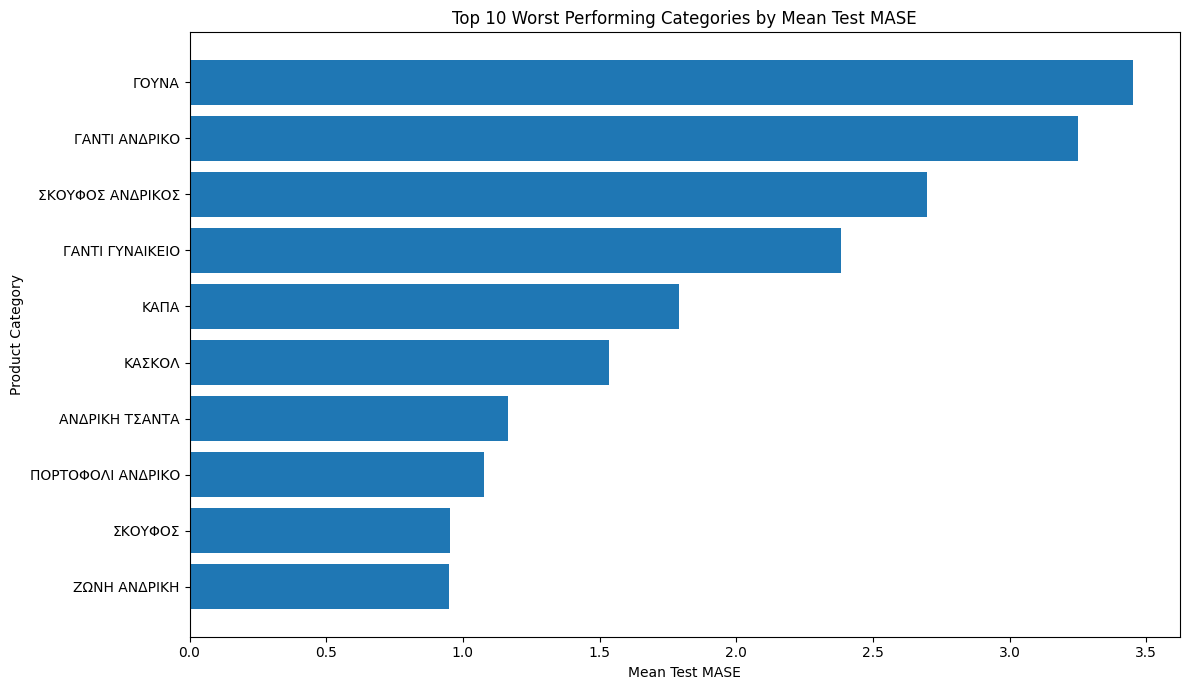

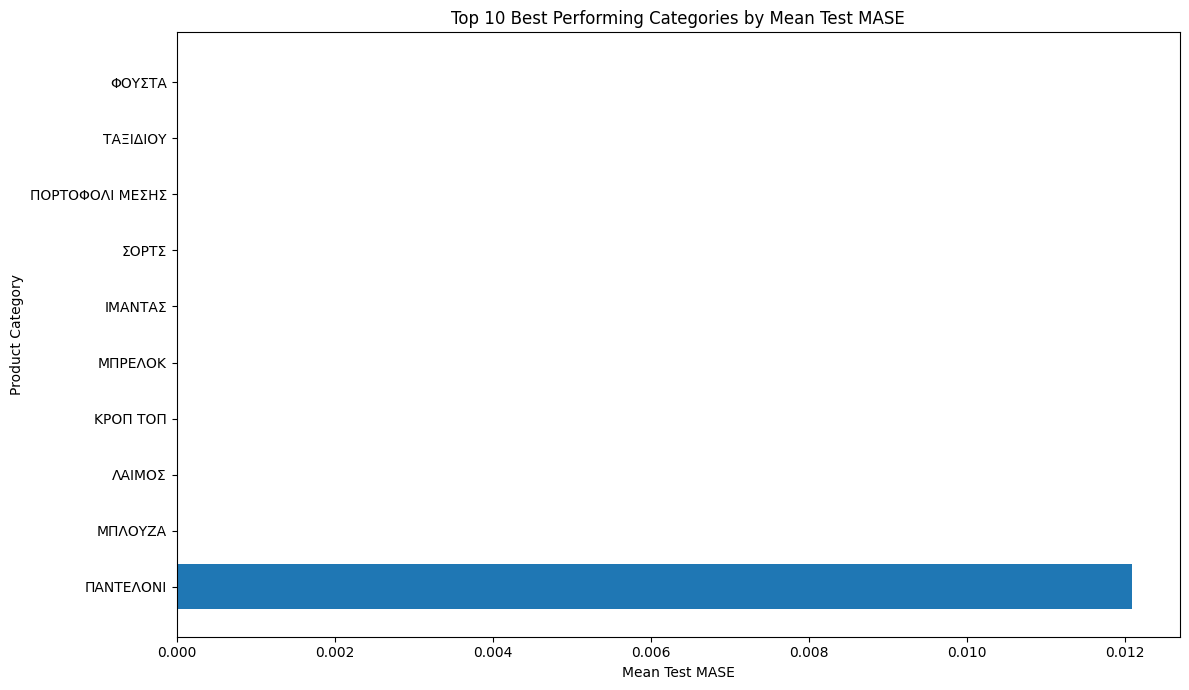

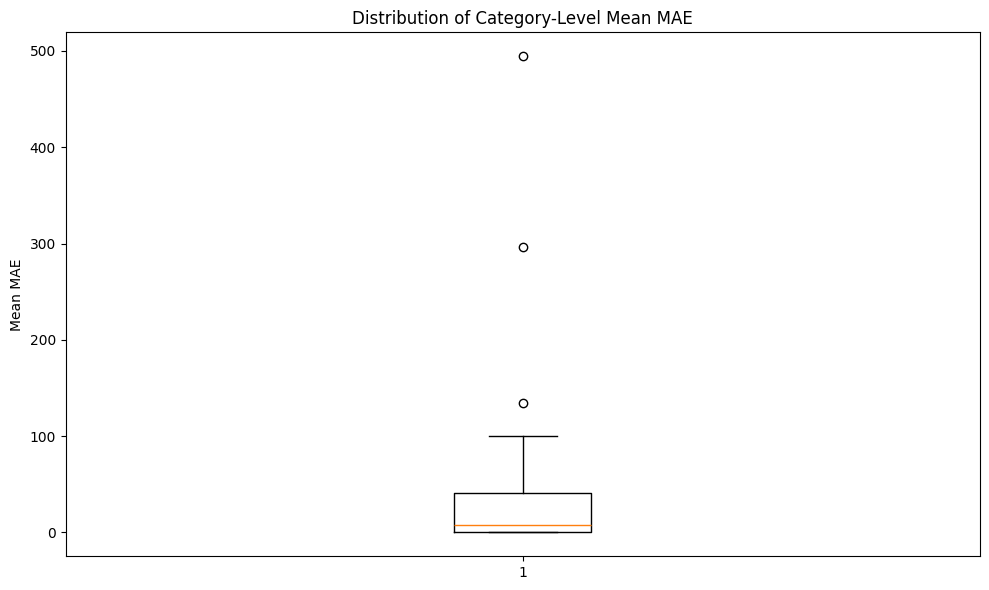

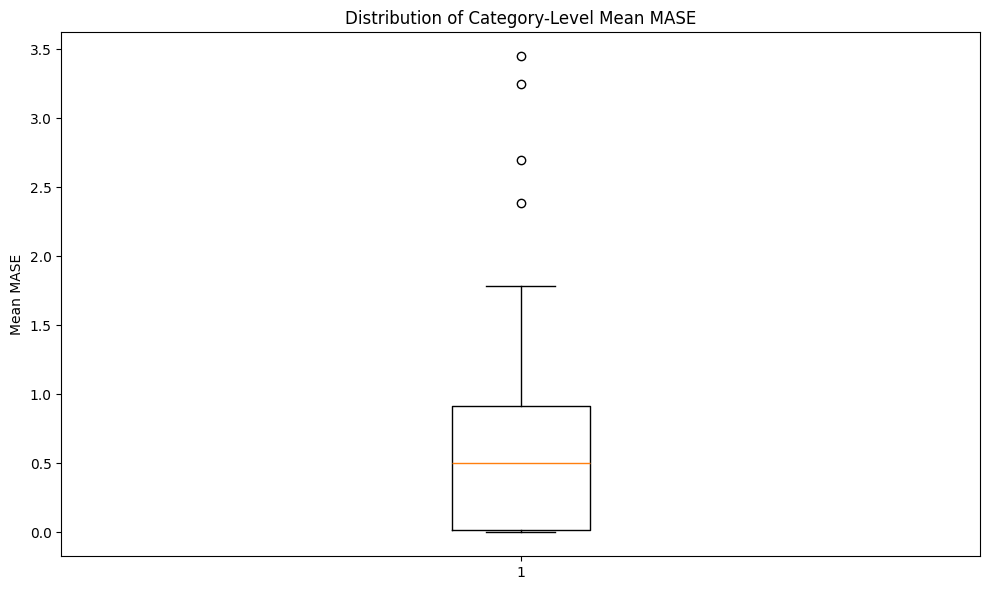


Category-model performance matrix:
selected_model_family  ARIMA_SARIMA       ETS  MovingAverage    Prophet  SeasonalNaive
Product Category                                                                      
AΜΠΙΓΙΕ                    0.375006  0.272461       1.238073        NaN       0.453728
POUCH                      0.677061       NaN       0.550906        NaN       0.527464
ΑΝΔΡΙΚΗ ΤΣΑΝΤΑ             1.093598  1.738317            NaN        NaN            NaN
ΓΑΝΤΙ ΑΝΔΡΙΚΟ              0.929877       NaN            NaN  11.692129       0.718437
ΓΑΝΤΙ ΓΥΝΑΙΚΕΙΟ            2.033657  4.744774       1.538286   2.501814            NaN

Model selection by category:
   Product Category selected_model_family  selection_count
1           AΜΠΙΓΙΕ                   ETS                3
0           AΜΠΙΓΙΕ          ARIMA_SARIMA                2
2           AΜΠΙΓΙΕ         MovingAverage                2
3           AΜΠΙΓΙΕ         SeasonalNaive                2
4             POUCH          A

In [14]:
if test_results_df.empty:
    raise ValueError("test_results_df is empty. Model 1 test results are required.")

category_error_summary = (
    test_results_df
    .groupby("Product Category", as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        mean_MASE=("MASE", "mean"),
        scenarios=("scenario_id", "count")
    )
    .sort_values("mean_MASE", ascending=False)
)

category_error_summary_file = MODEL_1_OUTPUT_DIR / "model_1_category_error_summary.csv"
category_error_summary.to_csv(
    category_error_summary_file,
    index=False,
    encoding="utf-8-sig"
)

print("\nCategory-level error summary:")
print(category_error_summary.head(10))

worst_categories = category_error_summary.head(10)

plt.figure(figsize=(12, 7))
plt.barh(
    worst_categories["Product Category"].astype(str),
    worst_categories["mean_MASE"]
)
plt.title("Top 10 Worst Performing Categories by Mean Test MASE")
plt.xlabel("Mean Test MASE")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    MODEL_1_OUTPUT_DIR / "plot_worst_categories_mase.png",
    dpi=150
)
plt.show()

best_categories = (
    category_error_summary
    .sort_values("mean_MASE", ascending=True)
    .head(10)
)

plt.figure(figsize=(12, 7))
plt.barh(
    best_categories["Product Category"].astype(str),
    best_categories["mean_MASE"]
)
plt.title("Top 10 Best Performing Categories by Mean Test MASE")
plt.xlabel("Mean Test MASE")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    MODEL_1_OUTPUT_DIR / "plot_best_categories_mase.png",
    dpi=150
)
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(category_error_summary["mean_MAE"].dropna())
plt.title("Distribution of Category-Level Mean MAE")
plt.ylabel("Mean MAE")
plt.tight_layout()
plt.savefig(
    MODEL_1_OUTPUT_DIR / "plot_category_mae_distribution.png",
    dpi=150
)
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(category_error_summary["mean_MASE"].dropna())
plt.title("Distribution of Category-Level Mean MASE")
plt.ylabel("Mean MASE")
plt.tight_layout()
plt.savefig(
    MODEL_1_OUTPUT_DIR / "plot_category_mase_distribution.png",
    dpi=150
)
plt.show()

category_model_matrix = (
    test_results_df
    .pivot_table(
        index="Product Category",
        columns="selected_model_family",
        values="MASE",
        aggfunc="mean"
    )
)

category_model_matrix_file = MODEL_1_OUTPUT_DIR / "model_1_category_model_matrix.csv"
category_model_matrix.to_csv(
    category_model_matrix_file,
    encoding="utf-8-sig"
)

print("\nCategory-model performance matrix:")
print(category_model_matrix.head())

model_selection_by_category = (
    test_results_df
    .groupby(["Product Category", "selected_model_family"], as_index=False)
    .agg(selection_count=("scenario_id", "count"))
    .sort_values(
        ["Product Category", "selection_count"],
        ascending=[True, False]
    )
)

model_selection_by_category_file = (
    MODEL_1_OUTPUT_DIR / "model_1_model_selection_by_category.csv"
)

model_selection_by_category.to_csv(
    model_selection_by_category_file,
    index=False,
    encoding="utf-8-sig"
)

print("\nModel selection by category:")
print(model_selection_by_category.head(20))